# Intro

DeiT (data-efficient image transformers) are more efficiently trained transformers for image classification, requiring far less data and far less computing resources compared to the original ViT models.

In this notebook, we implement a transfer learning workflow using a pre-trained Vision Transformer (DeiT). The primary objective is to evaluate the model's performance on our target dataset while utilizing Attention Rollout to interpret and visualize the model's decision-making process.

### Imports

In [1]:
import timm
import torch.nn as nn
import os
import torch
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import classification_report, average_precision_score, roc_auc_score
import math
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as patches
from pathlib import Path


### Load kedro

In [2]:
os.chdir("../../")

%load_ext kedro.ipython

[07/22/26 21:30:22] INFO     Using                                                                  ]8;id=566846;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=892519;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\framework\project\__init__.py#269\269]8;;\
                             'c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-pac                
                             kages\kedro\framework\project\rich_logging.yml' as logging                            
                             configuration.                                                                        

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=177277;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=778217;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#64\64]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=671515;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=280769;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#66\66]8;;\

                    INFO     Resolved project path as:                                              ]8;id=502618;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=532358;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#181\181]8;;\
                             c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\cxr-training-pipeli                
                             ne.                                                                                   
                             To set a different path, run '%reload_kedro <project_root>'                           

[07/22/26 21:30:27] WARNING  c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-pack ]8;id=249773;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=376415;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             ages\requests\__init__.py:113: RequestsDependencyWarning: urllib3                     
                             (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't                   
                             match a supported version!                                                            
                               warnings.warn(                                                                      
                                                                                                                   

...

                    WARNING  c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-pack ]8;id=126749;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=156340;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             ages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning:                   
                             The filesystem tracking backend (e.g., './mlruns') is deprecated as of                
                             February 2026. Consider transitioning to a database backend (e.g.,                    
                             'sqlite:///mlflow.db') to take advantage of the latest MLflow                         
                             features. See                                                                         
                             https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store                   
                             for migration guidance.                                                               
                               return FileStore(store_uri, store_uri)                                              
                                                                                                                   

[07/22/26 21:30:50] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=731146;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=519028;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro_telemetry\plugin.py#242\242]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

[07/22/26 21:30:51] INFO     Kedro project cxr-training-pipeline                                    ]8;id=281084;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=886830;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#147\147]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=33127;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=895015;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#148\148]8;;\
                             'pipelines'                                                                           

[07/22/26 21:30:52] INFO     Registered line magic 'run_viz'                                        ]8;id=615467;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=691887;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#154\154]8;;\

### Load data

In [3]:
train_val = catalog.load("xray_train_val")
test = catalog.load("xray_test")

                    INFO     Loading data from xray_train_val (CSVDataset)...                  ]8;id=725266;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=309526;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

                    INFO     Loading data from xray_test (CSVDataset)...                       ]8;id=229634;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=323347;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

In [4]:
train_val.head()

,image_index,finding_labels,Infiltration,Effusion,Atelectasis,Nodule,Mass,Pneumothorax,Consolidation,Pleural_Thickening,Cardiomegaly,Emphysema,Edema,Fibrosis,Pneumonia,Hernia
0,00000001_000.png,Cardiomegaly,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,00000001_001.png,Cardiomegaly|Emphysema,0,0,0,0,0,0,0,0,1,1,0,0,0,0
2,00000001_002.png,Cardiomegaly|Effusion,0,1,0,0,0,0,0,0,1,0,0,0,0,0
3,00000002_000.png,No Finding,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,00000004_000.png,Mass|Nodule,0,0,0,1,1,0,0,0,0,0,0,0,0,0


In [5]:
pathologies = ["Infiltration", "Effusion", "Atelectasis", "Nodule", "Mass", "Pneumothorax", "Consolidation", "Pleural_Thickening", "Cardiomegaly", "Emphysema", "Edema", "Fibrosis", "Pneumonia", "Hernia"]

print(len(pathologies))

14


In [6]:
def make_vector(row):
    """Create a binary pathology vector from a row."""
    vector = [0] * len(pathologies)
    for i, pathology in enumerate(pathologies):
        if row.get(pathology) == 1:
            vector[i] = 1
    return vector

In [7]:
train_val['pathology_vector'] = train_val.apply(make_vector, axis=1)
test['pathology_vector'] = test.apply(make_vector, axis=1)

In [8]:
train_val.head()

,image_index,finding_labels,Infiltration,Effusion,Atelectasis,Nodule,Mass,Pneumothorax,Consolidation,Pleural_Thickening,Cardiomegaly,Emphysema,Edema,Fibrosis,Pneumonia,Hernia,pathology_vector
0,00000001_000.png,Cardiomegaly,0,0,0,0,0,0,0,0,1,0,0,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]"
1,00000001_001.png,Cardiomegaly|Emphysema,0,0,0,0,0,0,0,0,1,1,0,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0]"
2,00000001_002.png,Cardiomegaly|Effusion,0,1,0,0,0,0,0,0,1,0,0,0,0,0,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]"
3,00000002_000.png,No Finding,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
4,00000004_000.png,Mass|Nodule,0,0,0,1,1,0,0,0,0,0,0,0,0,0,"[0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]"


In [9]:
test.head()

,image_index,finding_labels,Infiltration,Effusion,Atelectasis,Nodule,Mass,Pneumothorax,Consolidation,Pleural_Thickening,Cardiomegaly,Emphysema,Edema,Fibrosis,Pneumonia,Hernia,pathology_vector
0,00000003_001.png,Hernia,0,0,0,0,0,0,0,0,0,0,0,0,0,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]"
1,00000003_002.png,Hernia,0,0,0,0,0,0,0,0,0,0,0,0,0,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]"
2,00000003_003.png,Hernia|Infiltration,1,0,0,0,0,0,0,0,0,0,0,0,0,1,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]"
3,00000003_004.png,Hernia,0,0,0,0,0,0,0,0,0,0,0,0,0,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]"
4,00000003_005.png,Hernia,0,0,0,0,0,0,0,0,0,0,0,0,0,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]"


### Mask channel config

When `USE_MASK_CHANNEL=True`, the model receives a 4-channel tensor: RGB image + lung/organ mask (same convention as the Kedro `TensorCXRDataset` / `use_mask_channel` path).


In [11]:
# --- DeiT mask-channel configuration (aligned with Kedro pipeline) ---
USE_MASK_CHANNEL = True
IMAGE_SIZE = 224
CROPPED_TENSOR_DIR = "data/05_model_input/tensor_cropped_224"
MASK_TENSOR_DIR = "data/05_model_input/masks_cropped_224"

DEIT_MEAN_3CH = [0.485, 0.456, 0.406]
DEIT_STD_3CH = [0.229, 0.224, 0.225]
DEIT_MEAN = DEIT_MEAN_3CH + ([0.0] if USE_MASK_CHANNEL else [])
DEIT_STD = DEIT_STD_3CH + ([1.0] if USE_MASK_CHANNEL else [])
DEIT_IN_CHANS = 3 + (1 if USE_MASK_CHANNEL else 0)


def expand_patch_embed_for_mask(model: nn.Module) -> nn.Module:
    """Widen DeiT patch embedding from 3 to 4 input channels (ImageNet transfer)."""
    old_conv = model.patch_embed.proj
    new_conv = nn.Conv2d(
        4,
        old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=old_conv.bias is not None,
    )
    with torch.no_grad():
        new_conv.weight[:, :3].copy_(old_conv.weight)
        new_conv.weight[:, 3:4].copy_(old_conv.weight.mean(dim=1, keepdim=True))
        if old_conv.bias is not None:
            new_conv.bias.copy_(old_conv.bias)
    model.patch_embed.proj = new_conv
    return model


def ensure_rgb_image_tensor(tensor: torch.Tensor) -> torch.Tensor:
    """Convert a 1xHxW (or HxW) tensor to 3xHxW for DeiT."""
    if tensor.ndim == 2:
        tensor = tensor.unsqueeze(0)
    tensor = tensor.float()
    if tensor.max() > 1.5:
        tensor = tensor / 255.0
    if tensor.shape[0] == 1:
        tensor = tensor.repeat(3, 1, 1)
    elif tensor.shape[0] != 3:
        raise ValueError(f"Expected 1 or 3 channels, got {tensor.shape[0]}")
    return tensor


def load_mask_tensor(path: str) -> torch.Tensor:
    loaded = torch.load(path, map_location="cpu")
    if isinstance(loaded, dict):
        loaded = loaded.get("image", loaded)
    mask = loaded.float()
    if mask.max() > 1.5:
        mask = mask / 255.0
    if mask.ndim == 2:
        mask = mask.unsqueeze(0)
    return mask[:1]


def resolve_mask_path(row: pd.Series, mask_tensor_dir: str = MASK_TENSOR_DIR) -> str | None:
    if "mask_tensor_path" in row and pd.notna(row.get("mask_tensor_path")):
        return row["mask_tensor_path"]
    image_index = row["image_index"]
    candidate = os.path.join(
        mask_tensor_dir,
        image_index.replace(".png", "_cropped_mask.pt"),
    )
    return candidate if os.path.exists(candidate) else None


def concat_mask_channel(image: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    image = ensure_rgb_image_tensor(image)
    mask = load_mask_tensor(mask) if isinstance(mask, str) else mask
    if mask.shape[-2:] != image.shape[-2:]:
        mask = torch.nn.functional.interpolate(
            mask.unsqueeze(0),
            size=image.shape[-2:],
            mode="nearest",
        ).squeeze(0)
    return torch.cat([image, mask[:1]], dim=0)


def normalize_deit_tensor(tensor: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(DEIT_MEAN, dtype=tensor.dtype, device=tensor.device).view(-1, 1, 1)
    std = torch.tensor(DEIT_STD, dtype=tensor.dtype, device=tensor.device).view(-1, 1, 1)
    return (tensor - mean) / std


def merge_mask_paths(df: pd.DataFrame, tensor_df: pd.DataFrame) -> pd.DataFrame:
    merge_cols = ["image_index"]
    for col in ("image_tensor_path", "mask_tensor_path"):
        if col in tensor_df.columns:
            merge_cols.append(col)
    return df.merge(tensor_df[merge_cols].drop_duplicates("image_index"), on="image_index", how="left")


def build_deit_model_input_tensor(
    img_path: str,
    device: torch.device,
    mask_path: str | None = None,
    use_mask_channel: bool = USE_MASK_CHANNEL,
):
    orig_img = Image.open(img_path).convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE))
    image = transforms.ToTensor()(transforms.Grayscale(num_output_channels=3)(orig_img))

    if use_mask_channel:
        if mask_path is None:
            raise ValueError("mask_path is required when USE_MASK_CHANNEL=True")
        tensor = concat_mask_channel(image, load_mask_tensor(mask_path))
    else:
        tensor = image

    tensor = normalize_deit_tensor(tensor)
    return tensor.unsqueeze(0).to(device), orig_img


### Model and training

In [12]:
def create_model(pathologies: list[str], use_mask_channel: bool = USE_MASK_CHANNEL) -> nn.Module:
    """Create a DeiT model; optionally widen patch embedding for a mask channel."""
    model = timm.create_model(
        "deit_tiny_patch16_224",
        pretrained=True,
        in_chans=3,
        num_classes=len(pathologies),
    )
    if use_mask_channel:
        expand_patch_embed_for_mask(model)
    return model


def load_model(path: str, use_mask_channel: bool = USE_MASK_CHANNEL) -> nn.Module:
    """Load a model from a checkpoint file."""
    model = create_model(pathologies, use_mask_channel=use_mask_channel)
    model.load_state_dict(torch.load(path, weights_only=True))
    return model


In [13]:
model = create_model(pathologies, use_mask_channel=USE_MASK_CHANNEL)


[07/22/26 21:31:10] WARNING  Warning: You are sending unauthenticated requests to the HF Hub. Please   ]8;id=924309;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\huggingface_hub\utils\_http.py\_http.py]8;;\:]8;id=556288;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\huggingface_hub\utils\_http.py#916\916]8;;\
                             set a HF_TOKEN to enable higher rate limits and faster downloads.                     

In [14]:
model


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(4, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)

In [15]:
def set_seed(seed: int):
    """Set random seeds for reproducibility."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def split_data(train_val: pd.DataFrame, test_size: float = 0.25, random_state: int = 42):
    """Split the data into training and validation sets."""

    train_df, val_df = train_test_split(train_val, test_size=test_size, random_state=random_state)
    return train_df, val_df

def reduce_no_finding_in_data(train_df: pd.DataFrame, pathologies: list[str], ratio: float = 0.25, random_state: int = 42):
    """Reduce the number of all-zero "No Finding" samples in the training split."""
    no_finding_mask = train_df[pathologies].sum(axis=1) == 0
    finding_df = train_df.loc[~no_finding_mask]
    no_finding_df = train_df.loc[no_finding_mask]

    max_no_finding = int(len(finding_df) * ratio)

    if len(no_finding_df) > max_no_finding:
        no_finding_df = no_finding_df.sample(n=max_no_finding, random_state=random_state)

    reduced_train_df = (
        pd.concat([finding_df, no_finding_df], axis=0)
          .sample(frac=1.0, random_state=random_state)
          .reset_index(drop=True)
    )

    return reduced_train_df

def calculate_pos_weight(train_df: pd.DataFrame, pathologies: list[str]) -> torch.Tensor:
    """Calculate pos_weight for BCE loss."""
    pos_counts = train_df[pathologies].sum(axis=0)  # positive samples per class
    neg_counts = len(train_df) - pos_counts      # negative samples per class

    pos_weight = torch.tensor((neg_counts / (pos_counts + 1e-8)).to_numpy(), dtype=torch.float32)

    return pos_weight

set_seed(42)

train_df, val_df = split_data(train_val, test_size=0.25, random_state=42)

if USE_MASK_CHANNEL:
    tensor_train_val = catalog.load("tensor_train_val_dataset")
    tensor_test_df = catalog.load("tensor_test_dataset")
    train_df = merge_mask_paths(train_df, tensor_train_val)
    val_df = merge_mask_paths(val_df, tensor_train_val)
    test = merge_mask_paths(test, tensor_test_df)
    print("Merged mask_tensor_path columns from Kedro tensor datasets.")

no_findings_before = (train_df[pathologies].sum(axis=1) == 0).sum()
print(f"Train split before downsampling: {len(train_df)}")
print(f"  finding cases: {len(train_df) - no_findings_before}")
print(f"  no_finding cases: {no_findings_before}")

# train_df = reduce_no_finding_in_data(train_df, pathologies, ratio=0.25, random_state=42)

# no_findings_after = (train_df[pathologies].sum(axis=1) == 0).sum()
# print(f"Train split after downsampling: {len(train_df)}")
# print(f"  finding cases: {len(train_df) - no_findings_after}")
# print(f"  no_finding cases: {no_findings_after}")

pos_weight = calculate_pos_weight(train_df, pathologies)

print("BCE pos_weight:")
for pathology, weight in zip(pathologies, pos_weight):
    print(f"  {pathology}: {weight.item():.2f}")

[07/22/26 21:31:14] INFO     Loading data from tensor_train_val_dataset (CSVDataset)...        ]8;id=978508;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=924392;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

[07/22/26 21:31:15] INFO     Loading data from tensor_test_dataset (CSVDataset)...             ]8;id=559843;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=488989;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

Merged mask_tensor_path columns from Kedro tensor datasets.
Train split before downsampling: 64893
  finding cases: 26982
  no_finding cases: 37911
BCE pos_weight:
  Infiltration: 5.28
  Effusion: 9.00
  Atelectasis: 9.56
  Nodule: 17.20
  Mass: 20.42
  Pneumothorax: 31.97
  Consolidation: 29.73
  Pleural_Thickening: 38.16
  Cardiomegaly: 50.96
  Emphysema: 60.16
  Edema: 61.46
  Fibrosis: 68.18
  Pneumonia: 96.29
  Hernia: 629.03


### Custom Dataset for DeiT

In [16]:
class PathologyDataset(Dataset):
    """Custom dataset for loading chest X-rays with pathology labels.

    Supports either image files (PNG/JPG) or pre-saved `.pt` tensors.
    When `use_mask_channel=True`, concatenates a precomputed mask tensor
    (from `mask_tensor_path` column or `mask_tensor_dir`).
    """

    def __init__(
        self,
        dataframe,
        image_dir="data/01_raw/images",
        transform=None,
        normalize=None,
        use_mask_channel: bool = USE_MASK_CHANNEL,
        mask_tensor_dir: str = MASK_TENSOR_DIR,
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.use_mask_channel = use_mask_channel
        self.mask_tensor_dir = mask_tensor_dir
        self.base_transform = transform or transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.dataframe)

    def _load_tensor_file(self, path):
        loaded = torch.load(path, map_location="cpu")
        if isinstance(loaded, dict):
            for k in ("image", "tensor", "data"):
                if k in loaded:
                    loaded = loaded[k]
                    break
        if isinstance(loaded, Image.Image):
            img = loaded.convert('RGB')
            tensor = transforms.ToTensor()(img)
        elif isinstance(loaded, np.ndarray):
            arr = loaded
            if arr.ndim == 3 and arr.shape[2] in (1, 3):
                arr = np.transpose(arr, (2, 0, 1))
            tensor = torch.tensor(arr)
        elif isinstance(loaded, torch.Tensor):
            tensor = loaded
        else:
            raise RuntimeError(f"Unsupported tensor file content: {type(loaded)}")

        return ensure_rgb_image_tensor(tensor)

    def _finalize_image(self, image: torch.Tensor, row: pd.Series) -> torch.Tensor:
        if self.use_mask_channel:
            mask_path = resolve_mask_path(row, self.mask_tensor_dir)
            if mask_path is None:
                raise FileNotFoundError(
                    f"Mask tensor not found for {row['image_index']} (USE_MASK_CHANNEL=True)."
                )
            image = concat_mask_channel(image, load_mask_tensor(mask_path))
            return normalize_deit_tensor(image)

        mean = torch.tensor(DEIT_MEAN_3CH, dtype=image.dtype).view(3, 1, 1)
        std = torch.tensor(DEIT_STD_3CH, dtype=image.dtype).view(3, 1, 1)
        return (image - mean) / std

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_index = row['image_index']

        image_path = os.path.join(self.image_dir, image_index)
        stem_no_ext = os.path.splitext(image_path)[0]
        tensor_path_candidates = [image_path, stem_no_ext + '.pt']

        tensor_path = None
        for p in tensor_path_candidates:
            if os.path.exists(p) and p.lower().endswith('.pt'):
                tensor_path = p
                break
        if tensor_path is None and os.path.exists(stem_no_ext + '.pt'):
            tensor_path = stem_no_ext + '.pt'

        if tensor_path is not None:
            image = self._finalize_image(self._load_tensor_file(tensor_path), row)
        else:
            img_path = image_path
            if not os.path.exists(img_path):
                raise FileNotFoundError(f"Image not found: {img_path}")
            img = Image.open(img_path)
            if img.mode != 'L' and img.mode != 'RGB':
                img = img.convert('L')
            image = self._finalize_image(self.base_transform(img), row)

        pathology_vector = torch.tensor(row['pathology_vector'], dtype=torch.float32)

        return {
            'image': image,
            'labels': pathology_vector,
            'image_index': image_index
        }


In [14]:
train_dataset = PathologyDataset(
    train_df,
    image_dir="data/01_raw/images",
    use_mask_channel=USE_MASK_CHANNEL,
)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)

val_dataset = PathologyDataset(
    val_df,
    image_dir="data/01_raw/images",
    use_mask_channel=USE_MASK_CHANNEL,
)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

test_dataset = PathologyDataset(
    test,
    image_dir="data/01_raw/images",
    use_mask_channel=USE_MASK_CHANNEL,
)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
if USE_MASK_CHANNEL:
    sample = train_dataset[0]["image"]
    print(f"Input tensor shape (with mask): {tuple(sample.shape)}")

Train dataset size: 64893
Validation dataset size: 21631
Test dataset size: 25596


In [17]:
# --- Cropped .pt tensor dataset (recommended path when USE_MASK_CHANNEL=True) ---
class CroppedTensorDataset(Dataset):
    """Loads precomputed cropped image tensors saved as .pt files.

    Expects `image_tensor_path` / `mask_tensor_path` columns when available
    (merged from Kedro tensor datasets), or builds paths from `image_index`.
    """

    def __init__(
        self,
        dataframe,
        tensor_dir=CROPPED_TENSOR_DIR,
        mask_tensor_dir=MASK_TENSOR_DIR,
        use_mask_channel: bool = USE_MASK_CHANNEL,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.tensor_dir = tensor_dir
        self.mask_tensor_dir = mask_tensor_dir
        self.use_mask_channel = use_mask_channel

    def __len__(self):
        return len(self.df)

    def _resolve_image_path(self, row: pd.Series) -> str:
        if "image_tensor_path" in row and pd.notna(row.get("image_tensor_path")):
            return row["image_tensor_path"]
        return os.path.join(
            self.tensor_dir,
            row["image_index"].replace(".png", "_cropped.pt"),
        )

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        tensor_path = self._resolve_image_path(row)

        image = torch.load(tensor_path, map_location="cpu")
        if isinstance(image, dict):
            image = image.get("image", image)
        image = ensure_rgb_image_tensor(image)

        if self.use_mask_channel:
            mask_path = resolve_mask_path(row, self.mask_tensor_dir)
            if mask_path is None:
                raise FileNotFoundError(
                    f"Mask tensor not found for {row['image_index']} (USE_MASK_CHANNEL=True)."
                )
            image = concat_mask_channel(image, load_mask_tensor(mask_path))
            image = normalize_deit_tensor(image)
        else:
            mean = torch.tensor(DEIT_MEAN_3CH, dtype=image.dtype).view(3, 1, 1)
            std = torch.tensor(DEIT_STD_3CH, dtype=image.dtype).view(3, 1, 1)
            image = (image - mean) / std

        labels = torch.tensor(row["pathology_vector"], dtype=torch.float32)

        return {
            "image": image,
            "labels": labels,
            "image_index": row.get("image_index", tensor_path),
        }


cropped_train_dataset = CroppedTensorDataset(
    train_df,
    tensor_dir=CROPPED_TENSOR_DIR,
    use_mask_channel=USE_MASK_CHANNEL,
)
cropped_val_dataset = CroppedTensorDataset(
    val_df,
    tensor_dir=CROPPED_TENSOR_DIR,
    use_mask_channel=USE_MASK_CHANNEL,
)
cropped_test_dataset = CroppedTensorDataset(
    test,
    tensor_dir=CROPPED_TENSOR_DIR,
    use_mask_channel=USE_MASK_CHANNEL,
)

cropped_train_loader = DataLoader(cropped_train_dataset, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
cropped_val_loader = DataLoader(cropped_val_dataset, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)
cropped_test_loader = DataLoader(cropped_test_dataset, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

print(f"Cropped train/val/test sizes: {len(cropped_train_dataset)}, {len(cropped_val_dataset)}, {len(cropped_test_dataset)}")
if USE_MASK_CHANNEL:
    sample = cropped_train_dataset[0]["image"]
    print(f"Cropped input tensor shape (with mask): {tuple(sample.shape)}")

# --- How to train on cropped tensors ---
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = create_model(pathologies, use_mask_channel=USE_MASK_CHANNEL).to(device)
# criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
# run_training_pipeline(
#     model=model,
#     train_loader=cropped_train_loader,
#     val_loader=cropped_val_loader,
#     test_loader=cropped_test_loader,
#     criterion=criterion,
#     optimizer=optimizer,
#     num_epochs=5,
#     device=device,
#     save_path=r"deit_cropped_best.pth",
#     pathologies=pathologies,
# )


Cropped train/val/test sizes: 64893, 21631, 25596


[07/22/26 21:31:23] WARNING  C:\Users\barte\AppData\Local\Temp\ipykernel_14360\2358874790.py:36:    ]8;id=944112;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=312998;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             FutureWarning: You are using `torch.load` with `weights_only=False`                   
                             (the current default value), which uses the default pickle module                     
                             implicitly. It is possible to construct malicious pickle data which                   
                             will execute arbitrary code during unpickling (See                                    
                             https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-mod                
                             els for more details). In a future release, the default value for                     
                             `weights_only` will be flipped to `True`. This limits the functions                   
                             that could be executed during unpickling. Arbitrary objects will no                   
                             longer be allowed to be loaded via this mode unless they are                          
                             explicitly allowlisted by the user via                                                
                             `torch.serialization.add_safe_globals`. We recommend you start setting                
                             `weights_only=True` for any use case where you don't have full control                
                             of the loaded file. Please open an issue on GitHub for any issues                     
                             related to this experimental feature.                                                 
                               image = torch.load(tensor_path, map_location="cpu")                                 
                                                                                                                   

[07/22/26 21:31:24] WARNING  C:\Users\barte\AppData\Local\Temp\ipykernel_14360\2647418478.py:49:    ]8;id=586195;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=16235;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             FutureWarning: You are using `torch.load` with `weights_only=False`                   
                             (the current default value), which uses the default pickle module                     
                             implicitly. It is possible to construct malicious pickle data which                   
                             will execute arbitrary code during unpickling (See                                    
                             https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-mod                
                             els for more details). In a future release, the default value for                     
                             `weights_only` will be flipped to `True`. This limits the functions                   
                             that could be executed during unpickling. Arbitrary objects will no                   
                             longer be allowed to be loaded via this mode unless they are                          
                             explicitly allowlisted by the user via                                                
                             `torch.serialization.add_safe_globals`. We recommend you start setting                
                             `weights_only=True` for any use case where you don't have full control                
                             of the loaded file. Please open an issue on GitHub for any issues                     
                             related to this experimental feature.                                                 
                               loaded = torch.load(path, map_location="cpu")                                       
                                                                                                                   

Cropped input tensor shape (with mask): (4, 224, 224)


In [18]:

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    num_batches = 0

    for batch in tqdm(dataloader, desc="Train"):
        images = batch['image'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    return total_loss / max(1, num_batches)

def evaluate_epoch(model, dataloader, criterion, device, pathologies=None):
    model.eval()
    total_loss = 0.0
    num_batches = 0
    all_predicted = []
    all_scores = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluate"):
            images = batch['image'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            num_batches += 1

            scores = torch.sigmoid(outputs)
            preds = (scores > 0.5).float()
            all_predicted.extend(preds.cpu().numpy())
            all_scores.extend(scores.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / max(1, num_batches)

    report = None
    avg_precision = None
    auroc = None
    if pathologies is not None:
        y_true = np.array(all_labels)
        y_pred = np.array(all_predicted)
        y_score = np.array(all_scores)

        try:
            report = classification_report(
                y_true,
                y_pred,
                target_names=pathologies,
                zero_division=0
            )
        except Exception as e:
            report = f"Could not produce classification report: {e}"

        try:
            avg_precision = average_precision_score(y_true, y_score, average="macro")
        except Exception:
            avg_precision = float("nan")

        try:
            auroc = roc_auc_score(y_true, y_score, average="macro")
        except Exception:
            auroc = float("nan")

    return avg_loss, report, avg_precision, auroc


def run_training_pipeline(model, train_loader, val_loader, test_loader,
                          criterion, optimizer, num_epochs, device, save_path, pathologies):

    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        print(f"\n--- Epoch {epoch+1}/{num_epochs} ---")

        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        print(f"Train Loss: {train_loss:.4f}")

        val_loss, val_report, val_ap, val_auroc = evaluate_epoch(model, val_loader, criterion, device, pathologies)
        print(f"Val Loss: {val_loss:.4f}")
        print(f"Val AP: {val_ap:.4f}" if val_ap is not None else "Val AP: n/a")
        print(f"Val AUROC: {val_auroc:.4f}" if val_auroc is not None else "Val AUROC: n/a")

        if val_report:
            print("Validation classification report:\n", val_report)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            print(f"✨ New best model saved with val loss: {best_val_loss:.4f}")

    print("\n--- Testing on test set ---")
    test_loss, test_report, test_ap, test_auroc = evaluate_epoch(model, test_loader, criterion, device, pathologies)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test AP: {test_ap:.4f}" if test_ap is not None else "Test AP: n/a")
    print(f"Test AUROC: {test_auroc:.4f}" if test_auroc is not None else "Test AUROC: n/a")

    if test_report:
        print("Test classification report:\n", test_report)

    print("Training and evaluation complete!")


### Training on cropped

In [ ]:
import mlflow
from pathlib import Path

# Kedro-managed MLflow names
experiment_name = "deit-cropped-v3"
run_name = 'deit-cropped-v3'

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment(experiment_name)

def run_training_pipeline_with_patience(model, train_loader, val_loader, test_loader,
                                       criterion, optimizer, num_epochs, device, save_path,
                                       pathologies, patience=5):
    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        print(f"\n--- Epoch {epoch+1}/{num_epochs} ---")

        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        print(f"Train Loss: {train_loss:.4f}")
        mlflow.log_metric("train_loss", float(train_loss), step=epoch)

        val_loss, val_report, val_ap, val_auroc = evaluate_epoch(model, val_loader, criterion, device, pathologies)
        print(f"Val Loss: {val_loss:.4f}")
        print(f"Val AP: {val_ap:.4f}" if val_ap is not None else "Val AP: n/a")
        print(f"Val AUROC: {val_auroc:.4f}" if val_auroc is not None else "Val AUROC: n/a")
        if val_report:
            print("Validation classification report:\n", val_report)

        mlflow.log_metric("val_loss", float(val_loss), step=epoch)
        if val_ap is not None:
            mlflow.log_metric("val_ap", float(val_ap), step=epoch)
        if val_auroc is not None:
            mlflow.log_metric("val_auroc", float(val_auroc), step=epoch)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
            print(f"✨ New best model saved with val loss: {best_val_loss:.4f}")
            mlflow.log_metric("best_val_loss", float(best_val_loss), step=epoch)
        else:
            epochs_no_improve += 1
            print(f"No improvement for {epochs_no_improve} epoch(s).")

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered (patience={patience}).")
            break

    print("\n--- Testing on test set ---")
    # load best weights if available
    try:
        model.load_state_dict(torch.load(save_path, map_location=device))
    except Exception:
        pass

    test_loss, test_report, test_ap, test_auroc = evaluate_epoch(model, test_loader, criterion, device, pathologies)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test AP: {test_ap:.4f}" if test_ap is not None else "Test AP: n/a")
    print(f"Test AUROC: {test_auroc:.4f}" if test_auroc is not None else "Test AUROC: n/a")

    if test_report:
        print("Test classification report:\n", test_report)

    return best_val_loss, val_report, test_loss, test_report

with mlflow.start_run(run_name=run_name):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = create_model(pathologies, use_mask_channel=USE_MASK_CHANNEL).to(device)

    criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

    num_epochs = 45
    save_path = "deit_cropped_best.pth"
    patience = 10  # <-- set desired patience here

    # log config
    mlflow.log_params({
        "model_name": "deit_tiny_patch16_224",
        "train_loader": "cropped_train_loader",
        "val_loader": "cropped_val_loader",
        "test_loader": "cropped_test_loader",
        "lr": 1e-4,
        "weight_decay": 0.01,
        "batch_size": cropped_train_loader.batch_size,
        "num_epochs": num_epochs,
        "loss": "BCEWithLogitsLoss_pos_weighted",
        "patience": patience,
        "use_mask_channel": USE_MASK_CHANNEL,
        "in_chans": DEIT_IN_CHANS,
    })

    best_val_loss, val_report, test_loss, test_report = run_training_pipeline_with_patience(
        model=model,
        train_loader=cropped_train_loader,
        val_loader=cropped_val_loader,
        test_loader=cropped_test_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=num_epochs,
        device=device,
        save_path=save_path,
        pathologies=pathologies,
        patience=patience,
    )

    # log final evaluation numbers
    mlflow.log_metric("final_val_loss", float(best_val_loss))
    mlflow.log_metric("final_test_loss", float(test_loss))

    mlflow.log_text(val_report or "", "reports/val_classification_report.txt")
    mlflow.log_text(test_report or "", "reports/test_classification_report.txt")

    # log model file + pytorch model
    mlflow.log_artifact(save_path, artifact_path="checkpoints")
    mlflow.pytorch.log_model(model, artifact_path="model")


2026/05/24 23:00:21 INFO mlflow.tracking.fluent: Experiment with name 'deit-cropped-v3' does not exist. Creating a new experiment.



--- Epoch 1/45 ---


Train:   0%|          | 0/4056 [00:00<?, ?it/s]

[05/24/26 23:00:22] WARNING  C:\Users\barte\AppData\Local\Temp\ipykernel_12424\2086020471.py:30:    ]8;id=371845;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=112891;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             FutureWarning: You are using `torch.load` with `weights_only=False`                   
                             (the current default value), which uses the default pickle module                     
                             implicitly. It is possible to construct malicious pickle data which                   
                             will execute arbitrary code during unpickling (See                                    
                             https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-mod                
                             els for more details). In a future release, the default value for                     
                             `weights_only` will be flipped to `True`. This limits the functions                   
                             that could be executed during unpickling. Arbitrary objects will no                   
                             longer be allowed to be loaded via this mode unless they are                          
                             explicitly allowlisted by the user via                                                
                             `torch.serialization.add_safe_globals`. We recommend you start setting                
                             `weights_only=True` for any use case where you don't have full control                
                             of the loaded file. Please open an issue on GitHub for any issues                     
                             related to this experimental feature.                                                 
                               image = torch.load(tensor_path, map_location="cpu")                                 
                                                                                                                   

Train: 100%|██████████| 4056/4056 [10:18<00:00,  6.56it/s]


...

                    WARNING  C:\Users\barte\AppData\Local\Temp\ipykernel_12424\2086020471.py:30:    ]8;id=491428;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=895256;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             FutureWarning: You are using `torch.load` with `weights_only=False`                   
                             (the current default value), which uses the default pickle module                     
                             implicitly. It is possible to construct malicious pickle data which                   
                             will execute arbitrary code during unpickling (See                                    
                             https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-mod                
                             els for more details). In a future release, the default value for                     
                             `weights_only` will be flipped to `True`. This limits the functions                   
                             that could be executed during unpickling. Arbitrary objects will no                   
                             longer be allowed to be loaded via this mode unless they are                          
                             explicitly allowlisted by the user via                                                
                             `torch.serialization.add_safe_globals`. We recommend you start setting                
                             `weights_only=True` for any use case where you don't have full control                
                             of the loaded file. Please open an issue on GitHub for any issues                     
                             related to this experimental feature.                                                 
                               image = torch.load(tensor_path, map_location="cpu")                                 
                                                                                                                   

Evaluate: 100%|██████████| 1600/1600 [02:19<00:00, 11.48it/s]


Test Loss: 1.7591
Test AP: nan
Test AUROC: nan
Test classification report:
                     precision    recall  f1-score   support

      Infiltration       0.27      0.84      0.41      6112
          Effusion       0.25      0.92      0.39      4658
       Atelectasis       0.16      0.84      0.27      3279
            Nodule       0.07      0.77      0.13      1623
              Mass       0.09      0.66      0.16      1748
      Pneumothorax       0.17      0.72      0.28      2665
     Consolidation       0.09      0.91      0.17      1815
Pleural_Thickening       0.06      0.76      0.12      1143
      Cardiomegaly       0.08      0.87      0.15      1069
         Emphysema       0.06      0.75      0.11      1093
             Edema       0.07      0.90      0.13       925
          Fibrosis       0.03      0.77      0.06       435
         Pneumonia       0.03      0.89      0.05       555
            Hernia       0.01      0.45      0.02        86

         micro avg    

2026/05/25 04:28:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 04:28:28 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/25 04:28:29 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


🏃 View run deit-cropped-v3 at: http://127.0.0.1:5000/#/experiments/691650834065733993/runs/9f07963527d84eaa8fe44ff685832e2a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/691650834065733993


In [20]:
torch.save(model.state_dict(), os.path.join("data", "06_models", "deit_models", "deit_cropped_final.pth"))

### Trainind on non-cropped


In [20]:
def run_training_pipeline_with_patience(model, train_loader, val_loader, test_loader,
                                       criterion, optimizer, num_epochs, device, save_path,
                                       pathologies, patience=10):
    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        print(f"\n--- Epoch {epoch+1}/{num_epochs} ---")

        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        print(f"Train Loss: {train_loss:.4f}")
        mlflow.log_metric("train_loss", float(train_loss), step=epoch)

        val_loss, val_report, val_ap, val_auroc = evaluate_epoch(model, val_loader, criterion, device, pathologies)
        print(f"Val Loss: {val_loss:.4f}")
        print(f"Val AP: {val_ap:.4f}" if val_ap is not None else "Val AP: n/a")
        print(f"Val AUROC: {val_auroc:.4f}" if val_auroc is not None else "Val AUROC: n/a")
        if val_report:
            print("Validation classification report:\n", val_report)

        mlflow.log_metric("val_loss", float(val_loss), step=epoch)
        if val_ap is not None:
            mlflow.log_metric("val_ap", float(val_ap), step=epoch)
        if val_auroc is not None:
            mlflow.log_metric("val_auroc", float(val_auroc), step=epoch)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
            print(f"✨ New best model saved with val loss: {best_val_loss:.4f}")
            mlflow.log_metric("best_val_loss", float(best_val_loss), step=epoch)
        else:
            epochs_no_improve += 1
            print(f"No improvement for {epochs_no_improve} epoch(s).")

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered (patience={patience}).")
            break

    print("\n--- Testing on test set ---")
    # load best weights if available
    try:
        model.load_state_dict(torch.load(save_path, map_location=device))
    except Exception:
        pass

    test_loss, test_report, test_ap, test_auroc = evaluate_epoch(model, test_loader, criterion, device, pathologies)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test AP: {test_ap:.4f}" if test_ap is not None else "Test AP: n/a")
    print(f"Test AUROC: {test_auroc:.4f}" if test_auroc is not None else "Test AUROC: n/a")

    if test_report:
        print("Test classification report:\n", test_report)

    return best_val_loss, val_report, test_loss, test_report

In [ ]:
import mlflow
from pathlib import Path

# Kedro-managed MLflow names
experiment_name = "deit-full-v1.1"
run_name = 'deit-full-v1.1'

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment(experiment_name)


with mlflow.start_run(run_name=run_name):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = create_model(pathologies, use_mask_channel=USE_MASK_CHANNEL).to(device)

    criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

    num_epochs = 60
    save_path = "deit_full_best_1.1.pth"
    patience = 10  # <-- set desired patience here

    # log config
    mlflow.log_params({
        "model_name": "deit_tiny_patch16_224",
        "train_loader": "train_loader",
        "val_loader": "val_loader",
        "test_loader": "test_loader",
        "lr": 1e-4,
        "weight_decay": 0.01,
        "batch_size": cropped_train_loader.batch_size,
        "num_epochs": num_epochs,
        "loss": "BCEWithLogitsLoss_pos_weighted",
        "patience": patience,
        "use_mask_channel": USE_MASK_CHANNEL,
        "in_chans": DEIT_IN_CHANS,
    })

    best_val_loss, val_report, test_loss, test_report = run_training_pipeline_with_patience(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=num_epochs,
        device=device,
        save_path=save_path,
        pathologies=pathologies,
        patience=patience,
    )

    # log final evaluation numbers
    mlflow.log_metric("final_val_loss", float(best_val_loss))
    mlflow.log_metric("final_test_loss", float(test_loss))

    mlflow.log_text(val_report or "", "reports/val_classification_report.txt")
    mlflow.log_text(test_report or "", "reports/test_classification_report.txt")

    # log model file + pytorch model
    mlflow.log_artifact(save_path, artifact_path="checkpoints")
    mlflow.pytorch.log_model(model, artifact_path="model")



--- Epoch 1/60 ---


Train: 100%|██████████| 4056/4056 [27:26<00:00,  2.46it/s]


Train Loss: 1.2815


Evaluate: 100%|██████████| 1352/1352 [07:51<00:00,  2.87it/s]


Val Loss: 1.2290
Val AP: 0.0945
Val AUROC: 0.6978
Validation classification report:
                     precision    recall  f1-score   support

      Infiltration       0.22      0.58      0.32      3450
          Effusion       0.16      0.92      0.28      2168
       Atelectasis       0.14      0.88      0.24      2133
            Nodule       0.06      0.73      0.11      1142
              Mass       0.06      0.82      0.11      1005
      Pneumothorax       0.04      0.85      0.08       669
     Consolidation       0.06      0.84      0.11       740
Pleural_Thickening       0.04      0.77      0.08       585
      Cardiomegaly       0.03      0.87      0.06       458
         Emphysema       0.02      0.91      0.04       362
             Edema       0.05      0.83      0.09       339
          Fibrosis       0.02      0.85      0.04       313
         Pneumonia       0.01      0.79      0.02       209
            Hernia       0.00      0.82      0.01        38

         micr

...

[07/04/26 07:03:50] WARNING  C:\Users\barte\AppData\Local\Temp\ipykernel_6912\713553026.py:54:      ]8;id=358403;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=329658;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             FutureWarning: You are using `torch.load` with `weights_only=False`                   
                             (the current default value), which uses the default pickle module                     
                             implicitly. It is possible to construct malicious pickle data which                   
                             will execute arbitrary code during unpickling (See                                    
                             https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-mod                
                             els for more details). In a future release, the default value for                     
                             `weights_only` will be flipped to `True`. This limits the functions                   
                             that could be executed during unpickling. Arbitrary objects will no                   
                             longer be allowed to be loaded via this mode unless they are                          
                             explicitly allowlisted by the user via                                                
                             `torch.serialization.add_safe_globals`. We recommend you start setting                
                             `weights_only=True` for any use case where you don't have full control                
                             of the loaded file. Please open an issue on GitHub for any issues                     
                             related to this experimental feature.                                                 
                               model.load_state_dict(torch.load(save_path, map_location=device))                   
                                                                                                                   

Evaluate: 100%|██████████| 1600/1600 [09:15<00:00,  2.88it/s]


Test Loss: 1.6776
Test AP: 0.1467
Test AUROC: 0.6954
Test classification report:
                     precision    recall  f1-score   support

      Infiltration       0.30      0.77      0.43      6112
          Effusion       0.29      0.76      0.42      4658
       Atelectasis       0.20      0.67      0.31      3279
            Nodule       0.08      0.62      0.15      1623
              Mass       0.09      0.72      0.17      1748
      Pneumothorax       0.16      0.81      0.26      2665
     Consolidation       0.10      0.85      0.18      1815
Pleural_Thickening       0.07      0.71      0.12      1143
      Cardiomegaly       0.09      0.73      0.16      1069
         Emphysema       0.06      0.81      0.11      1093
             Edema       0.07      0.90      0.13       925
          Fibrosis       0.03      0.67      0.05       435
         Pneumonia       0.03      0.80      0.05       555
            Hernia       0.01      0.65      0.02        86

         micro a

2026/07/04 07:13:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/04 07:13:06 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/07/04 07:13:06 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


🏃 View run deit-full-v1.1 at: http://127.0.0.1:5000/#/experiments/456949952711730040/runs/b3aed42d78fe4b08bfc902c46911f304
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/456949952711730040


### Predictions

In [19]:
def predict_on_loader(model, dataloader, device):
    model.eval()

    all_predicted = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Predicting"):
            images = batch['image'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(images)
            predicted = (torch.sigmoid(outputs) > 0.5).float()

            all_predicted.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_predicted), np.array(all_labels)

def generate_classification_report(all_predicted: np.ndarray, all_labels: np.ndarray, pathologies: list[str]):
    try:
        report = classification_report(
            all_labels,
            all_predicted,
            target_names=pathologies,
            zero_division=0
        )
        return report
    except Exception as e:
        return f"Could not produce classification report: {e}"

def test_model(model, test_loader, device, pathologies):
    all_predicted, all_labels = predict_on_loader(model, test_loader, device)
    report = generate_classification_report(all_predicted, all_labels, pathologies)
    print("Test classification report:\n", report)

I have 3 models that i trained. Each of them was trained on the same dataset with 224x224 images:
- 6 epochs
- 15 epochs best val_loss
- 15 epoch last

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [19]:
first_6_epochs_model = load_model("data/06_models/deit_models/deit_tiny_chest_xray.pth").to(device)
second_15_epochs_best_model = load_model("data/06_models/deit_models/deit_tiny_chest_xray_bigger_epochs.pth").to(device)
third_15_epochs_model = load_model("data/06_models/deit_models/deit_tiny_chest_xray_bigger_epochs_last_version.pth").to(device)

In [21]:
cropped_with_mask_model = load_model("data/06_models/deit_models/deit_cropped_with_mask_final.pth").to(device)

In [20]:
cropped = load_model("data/06_models/deit_models/deit_cropped_final.pth").to(device)

In [44]:
print("Evaluating first 6 epochs model:")
test_model(first_6_epochs_model, test_loader, device, pathologies)

print("\nEvaluating second 15 epochs best model:")
test_model(second_15_epochs_best_model, test_loader, device, pathologies)

print("\nEvaluating third 15 epochs model:")
test_model(third_15_epochs_model, test_loader, device, pathologies)


Evaluating first 6 epochs model:


Predicting: 100%|██████████| 1600/1600 [10:28<00:00,  2.55it/s]


Test classification report:
                     precision    recall  f1-score   support

      Infiltration       0.30      0.65      0.41      6112
          Effusion       0.28      0.74      0.41      4658
       Atelectasis       0.20      0.58      0.30      3279
            Nodule       0.09      0.52      0.15      1623
              Mass       0.09      0.66      0.16      1748
      Pneumothorax       0.16      0.79      0.26      2665
     Consolidation       0.11      0.75      0.19      1815
Pleural_Thickening       0.07      0.75      0.12      1143
      Cardiomegaly       0.09      0.70      0.16      1069
         Emphysema       0.06      0.78      0.11      1093
             Edema       0.10      0.68      0.17       925
          Fibrosis       0.03      0.74      0.06       435
         Pneumonia       0.03      0.72      0.06       555
            Hernia       0.01      0.72      0.01        86

         micro avg       0.12      0.68      0.20     27206
         

Predicting: 100%|██████████| 1600/1600 [11:04<00:00,  2.41it/s]


Test classification report:
                     precision    recall  f1-score   support

      Infiltration       0.30      0.70      0.42      6112
          Effusion       0.31      0.69      0.43      4658
       Atelectasis       0.20      0.65      0.30      3279
            Nodule       0.09      0.59      0.16      1623
              Mass       0.11      0.59      0.19      1748
      Pneumothorax       0.18      0.81      0.30      2665
     Consolidation       0.11      0.69      0.20      1815
Pleural_Thickening       0.08      0.57      0.15      1143
      Cardiomegaly       0.10      0.72      0.18      1069
         Emphysema       0.07      0.68      0.13      1093
             Edema       0.08      0.84      0.14       925
          Fibrosis       0.04      0.40      0.08       435
         Pneumonia       0.04      0.53      0.07       555
            Hernia       0.02      0.12      0.03        86

         micro avg       0.15      0.68      0.24     27206
         

Predicting: 100%|██████████| 1600/1600 [11:20<00:00,  2.35it/s]

Test classification report:
                     precision    recall  f1-score   support

      Infiltration       0.32      0.65      0.43      6112
          Effusion       0.30      0.72      0.42      4658
       Atelectasis       0.20      0.60      0.30      3279
            Nodule       0.09      0.50      0.15      1623
              Mass       0.10      0.60      0.18      1748
      Pneumothorax       0.22      0.43      0.29      2665
     Consolidation       0.11      0.58      0.18      1815
Pleural_Thickening       0.08      0.41      0.14      1143
      Cardiomegaly       0.18      0.44      0.25      1069
         Emphysema       0.10      0.31      0.15      1093
             Edema       0.09      0.53      0.16       925
          Fibrosis       0.04      0.33      0.07       435
         Pneumonia       0.04      0.16      0.06       555
            Hernia       0.03      0.10      0.05        86

         micro avg       0.17      0.57      0.26     27206
         

### Grad-CAM / Attention Rollout on DEIT

In [22]:
bbox = catalog.load("cxr8_bbox")

[07/22/26 21:32:59] INFO     Loading data from cxr8_bbox (CSVDataset)...                       ]8;id=265792;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=901979;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

In [23]:
bbox

,image_index,finding_label,x,y,w,h
0,00013118_008.png,Atelectasis,225.084746,547.019217,86.779661,79.186441
1,00014716_007.png,Atelectasis,686.101695,131.543498,185.491525,313.491525
2,00029817_009.png,Atelectasis,221.830508,317.053115,155.118644,216.949153
3,00014687_001.png,Atelectasis,726.237288,494.951420,141.016949,55.322034
4,00017877_001.png,Atelectasis,660.067797,569.780787,200.677966,78.101695
...,...,...,...,...,...,...
979,00029464_015.png,Atelectasis,198.940451,352.900747,615.537778,323.128889
980,00025769_001.png,Atelectasis,701.838229,572.491858,103.537778,63.715556
981,00016837_002.png,Atelectasis,140.913785,658.962969,271.928889,94.435556
982,00020124_003.png,Atelectasis,175.047118,580.456302,244.622222,103.537778


In [94]:
IDX = 444

In [95]:
image_index = bbox['image_index'].iloc[IDX]

In [24]:
def get_attention_hook(attn_maps):
    """
    Creates a hook function that captures and saves attention weights from the attention module.
    """
    def _hook(module, input, output):
        x = input[0]  # (B, N, C)
        B, N, C = x.shape
        qkv = module.qkv(x)  # (B, N, 3*C)

        # Determine number of attention heads
        num_heads = getattr(module, "num_heads", None) or getattr(module, "num_attn_heads", None) or 3
        head_dim = C // num_heads

        qkv = qkv.reshape(B, N, 3, num_heads, head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]  # each: (B, num_heads, N, head_dim)

        attn = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(head_dim))
        attn = torch.softmax(attn, dim=-1)  # (B, num_heads, N, N)
        attn_maps.append(attn.detach().cpu())

    return _hook


def compute_attention_rollout(attn_maps):
    """
    Computes attention rollout from a list of attention maps.
    """
    attn_stack = [a[0].mean(0).numpy() for a in attn_maps]  # average heads, take batch 0
    num_tokens = attn_stack[0].shape[0]

    rollout = np.eye(num_tokens)
    for a in attn_stack:
        a_aug = a + np.eye(num_tokens)
        a_aug = a_aug / a_aug.sum(axis=-1, keepdims=True)
        rollout = a_aug @ rollout

    return rollout


def process_attention_map(rollout):
    """
    Extracts the attention mask from the class token and reshapes it to a spatial patch grid.
    """
    mask = rollout[0, 1:]  # shape (num_patches,)
    patch_size = int(math.sqrt(mask.shape[0]))
    cam = mask.reshape(patch_size, patch_size)

    # Min-max normalization
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam


def generate_overlay(orig_img, cam):
    """
    Creates the overlay image from the original image and the upscaled CAM.
    """
    cam_img = Image.fromarray(np.uint8(cm.jet(cam) * 255)).resize((224, 224), resample=Image.BILINEAR)
    cam_arr = np.array(cam_img)[..., :3]  # RGBA to RGB

    orig_arr = np.array(orig_img)
    overlay = (0.6 * orig_arr.astype(float) + 0.4 * cam_arr.astype(float)).astype(np.uint8)

    return cam, overlay


def plot_attention_rollout(model, img_path, bbox_row=None, mask_path=None):
    """
    Extracts attention maps, processes them, and plots the results including bounding box overlays.

    Parameters:
    -----------
    model : torch.nn.Module
        The model to use for attention extraction
    img_path : str
        Path to the image
    bbox_row : pd.Series, optional
        Series containing x, y, w, h coordinates for bounding box
    mask_path : str, optional
        Path to precomputed mask tensor (required when USE_MASK_CHANNEL=True)
    """
    model.eval()

    device = next(model.parameters()).device

    if mask_path is None and bbox_row is not None:
        mask_path = resolve_mask_path(bbox_row)

    img_tensor, orig_img = build_deit_model_input_tensor(
        img_path,
        device=device,
        mask_path=mask_path,
        use_mask_channel=USE_MASK_CHANNEL,
    )

    attn_maps = []
    handles = []
    hook_fn = get_attention_hook(attn_maps)

    for blk in model.blocks:
        handles.append(blk.attn.register_forward_hook(hook_fn))

    _ = model(img_tensor)

    for h in handles:
        h.remove()

    rollout = compute_attention_rollout(attn_maps)
    cam = process_attention_map(rollout)
    cam_normalized, overlay = generate_overlay(orig_img, cam)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 3, 1)
    plt.title("Original")
    plt.axis("off")
    plt.imshow(np.array(orig_img))

    plt.subplot(1, 3, 2)
    plt.title("Attention rollout (upsampled)")
    plt.axis("off")
    plt.imshow(cam, cmap="jet")

    plt.subplot(1, 3, 3)
    plt.title("Overlay")
    plt.axis("off")
    plt.imshow(overlay)

    # Add bounding box if provided
    if bbox_row is not None:
        try:
            x, y, w, h = bbox_row[["x", "y", "w", "h"]].astype(float)

            scale_factor = orig_img.size[0] / 1024
            x_min_scaled = int(round(x * scale_factor))
            y_min_scaled = int(round(y * scale_factor))
            x_max_scaled = int(round((x + w) * scale_factor))
            y_max_scaled = int(round((y + h) * scale_factor))

            rect = patches.Rectangle(
                (x_min_scaled, y_min_scaled),
                x_max_scaled - x_min_scaled,
                y_max_scaled - y_min_scaled,
                linewidth=2,
                edgecolor='cyan',
                facecolor='none'
            )
            ax = plt.subplot(1, 3, 3)
            ax.add_patch(rect)
        except Exception as e:
            print(f"Could not add bounding box: {e}")

    plt.tight_layout()
    plt.show()


In [52]:
bbox.head()

,image_index,finding_label,x,y,w,h
0,00013118_008.png,Atelectasis,225.084746,547.019217,86.779661,79.186441
1,00014716_007.png,Atelectasis,686.101695,131.543498,185.491525,313.491525
2,00029817_009.png,Atelectasis,221.830508,317.053115,155.118644,216.949153
3,00014687_001.png,Atelectasis,726.237288,494.951420,141.016949,55.322034
4,00017877_001.png,Atelectasis,660.067797,569.780787,200.677966,78.101695


In [25]:
def get_random_row(df: pd.DataFrame):
    """Get a random image path and its corresponding bounding box."""
    random_row = df.sample(n=1).iloc[0]

    return random_row

In [26]:
random_row = get_random_row(bbox)

image_path = os.path.join("data/01_raw/images", random_row['image_index'])


[07/22/26 21:33:12] WARNING  C:\Users\barte\AppData\Local\Temp\ipykernel_14360\2647418478.py:49:    ]8;id=217825;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=174967;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             FutureWarning: You are using `torch.load` with `weights_only=False`                   
                             (the current default value), which uses the default pickle module                     
                             implicitly. It is possible to construct malicious pickle data which                   
                             will execute arbitrary code during unpickling (See                                    
                             https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-mod                
                             els for more details). In a future release, the default value for                     
                             `weights_only` will be flipped to `True`. This limits the functions                   
                             that could be executed during unpickling. Arbitrary objects will no                   
                             longer be allowed to be loaded via this mode unless they are                          
                             explicitly allowlisted by the user via                                                
                             `torch.serialization.add_safe_globals`. We recommend you start setting                
                             `weights_only=True` for any use case where you don't have full control                
                             of the loaded file. Please open an issue on GitHub for any issues                     
                             related to this experimental feature.                                                 
                               loaded = torch.load(path, map_location="cpu")                                       
                                                                                                                   

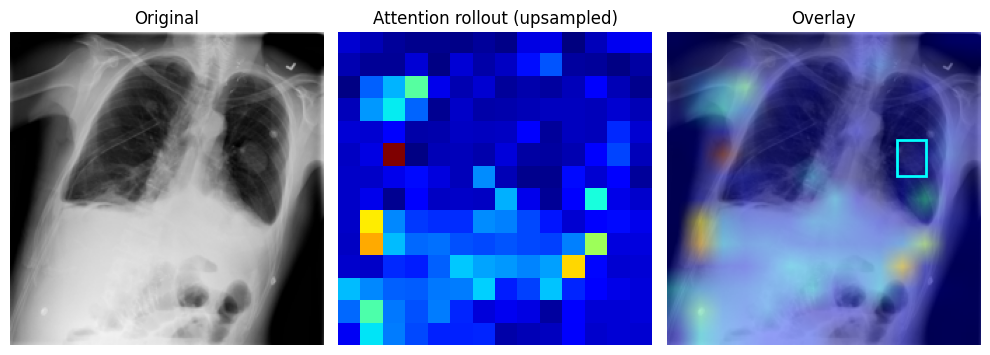

In [28]:
plot_attention_rollout(
    model=cropped_with_mask_model,
    img_path=image_path,
    bbox_row=random_row
)


In [29]:
def calculate_iou_bbox(attention_mask, bbox_row, threshold=None, top_percent=0.2, return_masks=False):
    H, W = attention_mask.shape
    x, y, w, h = bbox_row[["x", "y", "w", "h"]].astype(float)

    scale = H / 1024.0
    x1 = int(round(x * scale)); y1 = int(round(y * scale))
    x2 = int(round((x + w) * scale)); y2 = int(round((y + h) * scale))

    x1, x2 = np.clip([x1, x2], 0, W)
    y1, y2 = np.clip([y1, y2], 0, H)

    bbox_mask = np.zeros((H, W), dtype=bool)
    if x1 < x2 and y1 < y2:
        bbox_mask[y1:y2, x1:x2] = True

    if threshold is None:
        k = max(1, int(np.prod(attention_mask.shape) * top_percent))
        thresh = np.sort(attention_mask.ravel())[-k]
    else:
        thresh = float(threshold)

    attention_binary = attention_mask >= thresh

    inter = np.logical_and(attention_binary, bbox_mask).sum()
    union = np.logical_or(attention_binary, bbox_mask).sum()

    iou = float(inter) / (float(union) + 1e-8) if union > 0 else 0.0

    if return_masks:
        return iou, attention_binary, bbox_mask
    return iou



In [31]:
def calculate_iou_for_image(model, img_path, bbox_row, device, mask_path=None):
    model.eval()

    if mask_path is None:
        mask_path = resolve_mask_path(bbox_row)

    img_tensor, _ = build_deit_model_input_tensor(
        img_path,
        device=device,
        mask_path=mask_path,
        use_mask_channel=USE_MASK_CHANNEL,
    )

    attn_maps = []
    handles = []
    hook_fn = get_attention_hook(attn_maps)

    for blk in model.blocks:
        handles.append(blk.attn.register_forward_hook(hook_fn))

    with torch.no_grad():
        _ = model(img_tensor)

    for h in handles:
        h.remove()

    rollout = compute_attention_rollout(attn_maps)
    cam = process_attention_map(rollout)

    iou = calculate_iou_bbox(cam, bbox_row)
    return iou, cam


random_row = get_random_row(bbox)
image_path = os.path.join("data/01_raw/images", random_row["image_index"])

iou, attention_mask = calculate_iou_for_image(
    model=cropped_with_mask_model,
    img_path=image_path,
    bbox_row=random_row,
    device=device
)

print(f"IoU for image {random_row['image_index']}: {iou:.4f}")


[07/22/26 21:33:23] WARNING  C:\Users\barte\AppData\Local\Temp\ipykernel_14360\2647418478.py:49:    ]8;id=320821;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=268730;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             FutureWarning: You are using `torch.load` with `weights_only=False`                   
                             (the current default value), which uses the default pickle module                     
                             implicitly. It is possible to construct malicious pickle data which                   
                             will execute arbitrary code during unpickling (See                                    
                             https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-mod                
                             els for more details). In a future release, the default value for                     
                             `weights_only` will be flipped to `True`. This limits the functions                   
                             that could be executed during unpickling. Arbitrary objects will no                   
                             longer be allowed to be loaded via this mode unless they are                          
                             explicitly allowlisted by the user via                                                
                             `torch.serialization.add_safe_globals`. We recommend you start setting                
                             `weights_only=True` for any use case where you don't have full control                
                             of the loaded file. Please open an issue on GitHub for any issues                     
                             related to this experimental feature.                                                 
                               loaded = torch.load(path, map_location="cpu")                                       
                                                                                                                   

IoU for image 00011463_002.png: 0.2778


In [32]:
def calculate_average_iou(model, bbox_df):
    ious = []

    for idx in range(len(bbox_df)):
        row = bbox_df.iloc[idx]
        image_path = os.path.join("data/01_raw/images", row['image_index'])

        iou, _ = calculate_iou_for_image(
            model=model,
            img_path=image_path,
            bbox_row=row,
            device=device
        )

        ious.append(iou)

    ious = np.array(ious)
    return ious

def calculate_average_iou_per_bbox(model, bbox_df):
    ious = []


In [ ]:
ious_first_6_epochs = calculate_average_iou(first_6_epochs_model, bbox)
print(f"Average IoU for first 6 epochs model: {np.nanmean(ious_first_6_epochs):.4f}")

ious_second_15_epochs = calculate_average_iou(second_15_epochs_best_model, bbox)
print(f"Average IoU for second 15 epochs best model: {np.nanmean(ious_second_15_epochs):.4f}")

ious_third_15_epochs = calculate_average_iou(third_15_epochs_model, bbox)
print(f"Average IoU for third 15 epochs model: {np.nanmean(ious_third_15_epochs):.4f}")

Average IoU for first 6 epochs model: 0.1060
Average IoU for second 15 epochs best model: 0.0668
Average IoU for third 15 epochs model: 0.0643


In [33]:
def get_attention_map_for_image(model, img_path, device, mask_path=None, bbox_row=None):
    model.eval()
    if mask_path is None and bbox_row is not None:
        mask_path = resolve_mask_path(bbox_row)

    img_tensor, _ = build_deit_model_input_tensor(
        img_path,
        device=device,
        mask_path=mask_path,
        use_mask_channel=USE_MASK_CHANNEL,
    )
    attn_maps = []
    handles = []
    hook_fn = get_attention_hook(attn_maps)
    for blk in model.blocks:
        handles.append(blk.attn.register_forward_hook(hook_fn))
    with torch.no_grad():
        _ = model(img_tensor)
    for h in handles:
        h.remove()
    rollout = compute_attention_rollout(attn_maps)
    return process_attention_map(rollout)

def _union_bbox_mask(bbox_rows, attention_shape, original_size=1024):
    H, W = attention_shape
    scale = H / float(original_size)
    union = np.zeros((H, W), dtype=bool)
    for _, row in bbox_rows.iterrows():
        x, y, w, h = row[["x", "y", "w", "h"]].astype(float)
        x1 = int(round(x * scale)); y1 = int(round(y * scale))
        x2 = int(round((x + w) * scale)); y2 = int(round((y + h) * scale))
        x1, x2 = np.clip([x1, x2], 0, W)
        y1, y2 = np.clip([y1, y2], 0, H)
        if x1 < x2 and y1 < y2:
            union[y1:y2, x1:x2] = True
    return union
def calculate_average_iou_per_bbox(model, bbox_df, device, images_dir="data/01_raw/images", top_percent=0.2):
    attention_cache = {}
    rows = []
    for _, row in tqdm(bbox_df.iterrows(), total=len(bbox_df), desc="IoU per bbox"):
        image_index = row["image_index"]
        if image_index not in attention_cache:
            img_path = os.path.join(images_dir, image_index)
            attention_cache[image_index] = get_attention_map_for_image(
                model, img_path, device, bbox_row=row
            )
        cam = attention_cache[image_index]
        iou = calculate_iou_bbox(cam, row, top_percent=top_percent)
        rows.append({
            "image_index": image_index,
            "finding_label": row.get("finding_label"),
            "iou": iou,
        })
    per_bbox_df = pd.DataFrame(rows)
    mean_iou = float(per_bbox_df["iou"].mean())
    return per_bbox_df, mean_iou

def calculate_average_iou_per_image(model, bbox_df, device, images_dir="data/01_raw/images", top_percent=0.2):

    rows = []
    grouped = bbox_df.groupby("image_index", sort=False)
    for image_index, image_rows in tqdm(grouped, total=grouped.ngroups, desc="IoU per image"):
        img_path = os.path.join(images_dir, image_index)
        cam = get_attention_map_for_image(
            model, img_path, device, bbox_row=image_rows.iloc[0]
        )
        # binarize attention (ta sama logika co w calculate_iou_bbox)
        k = max(1, int(np.prod(cam.shape) * top_percent))
        thresh = np.sort(cam.ravel())[-k]
        attention_binary = cam >= thresh
        gt_union = _union_bbox_mask(image_rows, cam.shape)
        inter = np.logical_and(attention_binary, gt_union).sum()
        union = np.logical_or(attention_binary, gt_union).sum()
        iou = float(inter) / (float(union) + 1e-8) if union > 0 else 0.0
        rows.append({
            "image_index": image_index,
            "n_bboxes": len(image_rows),
            "iou": iou,
        })
    per_image_df = pd.DataFrame(rows)
    mean_iou = float(per_image_df["iou"].mean())
    return per_image_df, mean_iou

In [32]:
# DEIT - full
per_bbox_df, mean_iou_bbox = calculate_average_iou_per_bbox(third_15_epochs_model, bbox, device)
per_image_df, mean_iou_image = calculate_average_iou_per_image(third_15_epochs_model, bbox, device)
print(f"Mean IoU per bbox:  {mean_iou_bbox:.4f}  (n={len(per_bbox_df)})")
print(f"Mean IoU per image: {mean_iou_image:.4f}  (n={len(per_image_df)})")

# DEIT - cropped
per_bbox_df, mean_iou_bbox = calculate_average_iou_per_bbox(cropped, bbox, device)
per_image_df, mean_iou_image = calculate_average_iou_per_image(cropped, bbox, device)
print(f"Mean IoU per bbox:  {mean_iou_bbox:.4f}  (n={len(per_bbox_df)})")
print(f"Mean IoU per image: {mean_iou_image:.4f}  (n={len(per_image_df)})")

IoU per image: 100%|██████████| 880/880 [01:42<00:00,  8.55it/s]


Mean IoU per bbox:  0.0643  (n=984)
Mean IoU per image: 0.0671  (n=880)


IoU per image: 100%|██████████| 880/880 [01:25<00:00, 10.26it/s]

Mean IoU per bbox:  0.0457  (n=984)
Mean IoU per image: 0.0481  (n=880)


In [34]:
# DEIT CROPPED WITH MASK
per_bbox_df, mean_iou_bbox = calculate_average_iou_per_bbox(cropped_with_mask_model, bbox, device)
per_image_df, mean_iou_image = calculate_average_iou_per_image(cropped_with_mask_model, bbox, device)
print(f"Mean IoU per bbox:  {mean_iou_bbox:.4f}  (n={len(per_bbox_df)})")
print(f"Mean IoU per image: {mean_iou_image:.4f}  (n={len(per_image_df)})")

                    WARNING  C:\Users\barte\AppData\Local\Temp\ipykernel_14360\2647418478.py:49:    ]8;id=462301;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=172675;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             FutureWarning: You are using `torch.load` with `weights_only=False`                   
                             (the current default value), which uses the default pickle module                     
                             implicitly. It is possible to construct malicious pickle data which                   
                             will execute arbitrary code during unpickling (See                                    
                             https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-mod                
                             els for more details). In a future release, the default value for                     
                             `weights_only` will be flipped to `True`. This limits the functions                   
                             that could be executed during unpickling. Arbitrary objects will no                   
                             longer be allowed to be loaded via this mode unless they are                          
                             explicitly allowlisted by the user via                                                
                             `torch.serialization.add_safe_globals`. We recommend you start setting                
                             `weights_only=True` for any use case where you don't have full control                
                             of the loaded file. Please open an issue on GitHub for any issues                     
                             related to this experimental feature.                                                 
                               loaded = torch.load(path, map_location="cpu")                                       
                                                                                                                   

IoU per image:  29%|██▉       | 253/880 [00:30<01:06,  9.43it/s]

                    WARNING  C:\Users\barte\AppData\Local\Temp\ipykernel_14360\2647418478.py:49:    ]8;id=964653;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=157673;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             FutureWarning: You are using `torch.load` with `weights_only=False`                   
                             (the current default value), which uses the default pickle module                     
                             implicitly. It is possible to construct malicious pickle data which                   
                             will execute arbitrary code during unpickling (See                                    
                             https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-mod                
                             els for more details). In a future release, the default value for                     
                             `weights_only` will be flipped to `True`. This limits the functions                   
                             that could be executed during unpickling. Arbitrary objects will no                   
                             longer be allowed to be loaded via this mode unless they are                          
                             explicitly allowlisted by the user via                                                
                             `torch.serialization.add_safe_globals`. We recommend you start setting                
                             `weights_only=True` for any use case where you don't have full control                
                             of the loaded file. Please open an issue on GitHub for any issues                     
                             related to this experimental feature.                                                 
                               loaded = torch.load(path, map_location="cpu")                                       
                                                                                                                   

IoU per image:  29%|██▉       | 254/880 [00:30<01:33,  6.67it/s]

                    WARNING  C:\Users\barte\AppData\Local\Temp\ipykernel_14360\2647418478.py:49:    ]8;id=798739;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=732574;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             FutureWarning: You are using `torch.load` with `weights_only=False`                   
                             (the current default value), which uses the default pickle module                     
                             implicitly. It is possible to construct malicious pickle data which                   
                             will execute arbitrary code during unpickling (See                                    
                             https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-mod                
                             els for more details). In a future release, the default value for                     
                             `weights_only` will be flipped to `True`. This limits the functions                   
                             that could be executed during unpickling. Arbitrary objects will no                   
                             longer be allowed to be loaded via this mode unless they are                          
                             explicitly allowlisted by the user via                                                
                             `torch.serialization.add_safe_globals`. We recommend you start setting                
                             `weights_only=True` for any use case where you don't have full control                
                             of the loaded file. Please open an issue on GitHub for any issues                     
                             related to this experimental feature.                                                 
                               loaded = torch.load(path, map_location="cpu")                                       
                                                                                                                   

...

IoU per image: 100%|█████████▉| 878/880 [01:36<00:00,  9.12it/s]

[07/22/26 21:37:28] WARNING  C:\Users\barte\AppData\Local\Temp\ipykernel_14360\2647418478.py:49:    ]8;id=990577;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=257769;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             FutureWarning: You are using `torch.load` with `weights_only=False`                   
                             (the current default value), which uses the default pickle module                     
                             implicitly. It is possible to construct malicious pickle data which                   
                             will execute arbitrary code during unpickling (See                                    
                             https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-mod                
                             els for more details). In a future release, the default value for                     
                             `weights_only` will be flipped to `True`. This limits the functions                   
                             that could be executed during unpickling. Arbitrary objects will no                   
                             longer be allowed to be loaded via this mode unless they are                          
                             explicitly allowlisted by the user via                                                
                             `torch.serialization.add_safe_globals`. We recommend you start setting                
                             `weights_only=True` for any use case where you don't have full control                
                             of the loaded file. Please open an issue on GitHub for any issues                     
                             related to this experimental feature.                                                 
                               loaded = torch.load(path, map_location="cpu")                                       
                                                                                                                   

                    WARNING  C:\Users\barte\AppData\Local\Temp\ipykernel_14360\2647418478.py:49:    ]8;id=502269;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=34511;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             FutureWarning: You are using `torch.load` with `weights_only=False`                   
                             (the current default value), which uses the default pickle module                     
                             implicitly. It is possible to construct malicious pickle data which                   
                             will execute arbitrary code during unpickling (See                                    
                             https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-mod                
                             els for more details). In a future release, the default value for                     
                             `weights_only` will be flipped to `True`. This limits the functions                   
                             that could be executed during unpickling. Arbitrary objects will no                   
                             longer be allowed to be loaded via this mode unless they are                          
                             explicitly allowlisted by the user via                                                
                             `torch.serialization.add_safe_globals`. We recommend you start setting                
                             `weights_only=True` for any use case where you don't have full control                
                             of the loaded file. Please open an issue on GitHub for any issues                     
                             related to this experimental feature.                                                 
                               loaded = torch.load(path, map_location="cpu")                                       
                                                                                                                   

IoU per image: 100%|██████████| 880/880 [01:36<00:00,  9.14it/s]

Mean IoU per bbox:  0.0652  (n=984)
Mean IoU per image: 0.0688  (n=880)


In [35]:
print(f"Mean IoU per bbox:  {mean_iou_bbox:.4f}  (n={len(per_bbox_df)})")
print(f"Mean IoU per image: {mean_iou_image:.4f}  (n={len(per_image_df)})")

Mean IoU per bbox:  0.0652  (n=984)
Mean IoU per image: 0.0688  (n=880)


### DeIT with masks as additional input

In [21]:
import mlflow

USE_MASK_CHANNEL = True

assert USE_MASK_CHANNEL

experiment_name = "deit-cropped-with-mask-v1"
run_name = "deit-cropped-with-mask-v1"

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment(experiment_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_model(pathologies, use_mask_channel=True).to(device)

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

num_epochs = 100
patience = 10
save_path = "deit_cropped_with_mask_best.pth"

# sanity check: input should be [4, 224, 224]
sample_batch = next(iter(cropped_train_loader))
print(f"Input shape: {tuple(sample_batch['image'].shape[1:])}")
assert sample_batch["image"].shape[1] == DEIT_IN_CHANS == 4

with mlflow.start_run(run_name=run_name):
    mlflow.log_params({
        "model_name": "deit_tiny_patch16_224",
        "train_loader": "cropped_train_loader",
        "val_loader": "cropped_val_loader",
        "test_loader": "cropped_test_loader",
        "tensor_dir": CROPPED_TENSOR_DIR,
        "mask_tensor_dir": MASK_TENSOR_DIR,
        "lr": 1e-4,
        "weight_decay": 0.01,
        "batch_size": cropped_train_loader.batch_size,
        "num_epochs": num_epochs,
        "patience": patience,
        "loss": "BCEWithLogitsLoss_pos_weighted",
        "use_mask_channel": True,
        "in_chans": DEIT_IN_CHANS,
    })

    best_val_loss, val_report, test_loss, test_report = run_training_pipeline_with_patience(
        model=model,
        train_loader=cropped_train_loader,
        val_loader=cropped_val_loader,
        test_loader=cropped_test_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=num_epochs,
        device=device,
        save_path=save_path,
        pathologies=pathologies,
        patience=patience,
    )

    mlflow.log_metric("final_val_loss", float(best_val_loss))
    mlflow.log_metric("final_test_loss", float(test_loss))
    mlflow.log_text(val_report or "", "reports/val_classification_report.txt")
    mlflow.log_text(test_report or "", "reports/test_classification_report.txt")
    mlflow.log_artifact(save_path, artifact_path="checkpoints")
    mlflow.pytorch.log_model(model, artifact_path="model")

os.makedirs(os.path.join("data", "06_models", "deit_models"), exist_ok=True)
final_path = os.path.join("data", "06_models", "deit_models", "deit_cropped_with_mask_final.pth")
torch.save(model.state_dict(), final_path)

print(f"Best checkpoint: {save_path}")
print(f"Final weights:   {final_path}")


[07/20/26 13:24:19] WARNING  C:\Users\barte\AppData\Local\Temp\ipykernel_22040\2358874790.py:36:    ]8;id=585256;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=692654;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             FutureWarning: You are using `torch.load` with `weights_only=False`                   
                             (the current default value), which uses the default pickle module                     
                             implicitly. It is possible to construct malicious pickle data which                   
                             will execute arbitrary code during unpickling (See                                    
                             https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-mod                
                             els for more details). In a future release, the default value for                     
                             `weights_only` will be flipped to `True`. This limits the functions                   
                             that could be executed during unpickling. Arbitrary objects will no                   
                             longer be allowed to be loaded via this mode unless they are                          
                             explicitly allowlisted by the user via                                                
                             `torch.serialization.add_safe_globals`. We recommend you start setting                
                             `weights_only=True` for any use case where you don't have full control                
                             of the loaded file. Please open an issue on GitHub for any issues                     
                             related to this experimental feature.                                                 
                               image = torch.load(tensor_path, map_location="cpu")                                 
                                                                                                                   

                    WARNING  C:\Users\barte\AppData\Local\Temp\ipykernel_22040\2647418478.py:49:    ]8;id=655113;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=271191;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             FutureWarning: You are using `torch.load` with `weights_only=False`                   
                             (the current default value), which uses the default pickle module                     
                             implicitly. It is possible to construct malicious pickle data which                   
                             will execute arbitrary code during unpickling (See                                    
                             https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-mod                
                             els for more details). In a future release, the default value for                     
                             `weights_only` will be flipped to `True`. This limits the functions                   
                             that could be executed during unpickling. Arbitrary objects will no                   
                             longer be allowed to be loaded via this mode unless they are                          
                             explicitly allowlisted by the user via                                                
                             `torch.serialization.add_safe_globals`. We recommend you start setting                
                             `weights_only=True` for any use case where you don't have full control                
                             of the loaded file. Please open an issue on GitHub for any issues                     
                             related to this experimental feature.                                                 
                               loaded = torch.load(path, map_location="cpu")                                       
                                                                                                                   

Input shape: (4, 224, 224)

--- Epoch 1/100 ---


Train: 100%|██████████| 4056/4056 [14:30<00:00,  4.66it/s]


Train Loss: 1.2857


...

                    WARNING  C:\Users\barte\AppData\Local\Temp\ipykernel_22040\2647418478.py:49:    ]8;id=304930;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=881707;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             FutureWarning: You are using `torch.load` with `weights_only=False`                   
                             (the current default value), which uses the default pickle module                     
                             implicitly. It is possible to construct malicious pickle data which                   
                             will execute arbitrary code during unpickling (See                                    
                             https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-mod                
                             els for more details). In a future release, the default value for                     
                             `weights_only` will be flipped to `True`. This limits the functions                   
                             that could be executed during unpickling. Arbitrary objects will no                   
                             longer be allowed to be loaded via this mode unless they are                          
                             explicitly allowlisted by the user via                                                
                             `torch.serialization.add_safe_globals`. We recommend you start setting                
                             `weights_only=True` for any use case where you don't have full control                
                             of the loaded file. Please open an issue on GitHub for any issues                     
                             related to this experimental feature.                                                 
                               loaded = torch.load(path, map_location="cpu")                                       
                                                                                                                   

Evaluate: 100%|██████████| 1600/1600 [04:54<00:00,  5.44it/s]


Test Loss: 1.7313
Test AP: 0.1600
Test AUROC: 0.7210
Test classification report:
                     precision    recall  f1-score   support

      Infiltration       0.28      0.87      0.42      6112
          Effusion       0.26      0.91      0.40      4658
       Atelectasis       0.18      0.82      0.29      3279
            Nodule       0.09      0.61      0.15      1623
              Mass       0.10      0.67      0.18      1748
      Pneumothorax       0.20      0.68      0.31      2665
     Consolidation       0.10      0.90      0.18      1815
Pleural_Thickening       0.08      0.67      0.14      1143
      Cardiomegaly       0.09      0.83      0.17      1069
         Emphysema       0.08      0.63      0.14      1093
             Edema       0.06      0.94      0.11       925
          Fibrosis       0.04      0.53      0.08       435
         Pneumonia       0.03      0.83      0.05       555
            Hernia       0.01      0.67      0.02        86

         micro a

2026/07/20 19:44:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/20 19:44:08 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/07/20 19:44:08 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


🏃 View run deit-cropped-with-mask-v1 at: http://127.0.0.1:5000/#/experiments/476717551017533420/runs/595487abb77849aca6db929be8b02e36
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/476717551017533420
Best checkpoint: deit_cropped_with_mask_best.pth
Final weights:   data\06_models\deit_models\deit_cropped_with_mask_final.pth
